In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) 

import matplotlib.pyplot as plt
import seaborn as sns
from src import *
import numpy as np


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathptmx}",  # Times Roman
    "hatch.linewidth": 3.0,
})
sns.set_context("paper",font_scale=1.5)
sns.set_palette("pastel")

# 1. Simulate population

In [ ]:
### 1. initiate some params
# bounds
a0_pop_min=10
a0_pop_max=16
log_mbh_min = 8
log_mbh_max = 9

# time,rate,pop size
t=1
tR=1
popN=10000
rates = np.logspace(-1,1,50)

### 2. simulate input data as uniform
# high z pop
np.random.seed(0)
a0_pop = np.random.uniform(a0_pop_min,a0_pop_max,popN)
log_mbh_sec_pop = np.random.uniform(log_mbh_min,log_mbh_max,popN)
mbh_pop= 10**log_mbh_sec_pop
q_pop = np.random.uniform(1,100,popN)

# low z pop
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)

### 3. similate predicted p(af)
# define a grid of a for calculating pdfs
ap = np.linspace(0,a0_pop.max()+3,200,endpoint=True)
# estimate observed a0, assuming perfect observation
p_a0_obs = scp_kde(a0_pop,ap,return_func=True)
p_a0_obs_val = p_a0_obs(ap)
#predict p(af) at different rates
p_af_preds = paf_analytic_allrates_mbhrange(p_a0_obs,a0_pop_min,a0_pop_max,
                                            log_mbh_min, log_mbh_max,
                                            t,af_grid=ap,
                                            Naf=50,Na0=2000,uniform=True,
                                            rates=np.logspace(-1,1,10))

### unit tests

(100, 1000, 20)


''

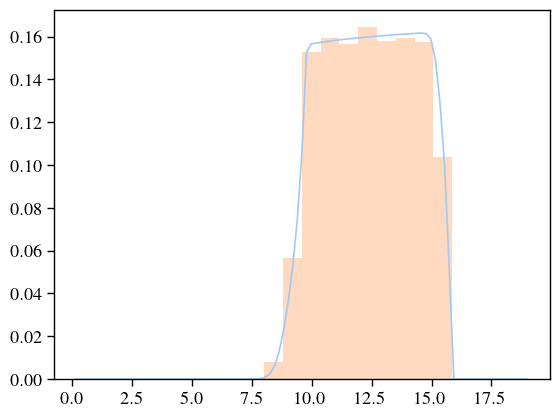

In [ ]:
af_pop = af_from_a0(a0_pop,10**log_mbh_sec_pop,t=t,R=tR)
_,paf = p_af_sigma_a0_mbhrange_unif_fast(a0_pop_min,a0_pop_max,log_mbh_min,log_mbh_max,t,tR,None)
plt.plot(_,paf)
plt.hist(af_pop,density=True,alpha=0.5)
# plt.plot(ap,p_a0_obs_val,c='b',alpha=0.5)
# plt.plot(ap,scp_kde(af_pop,ap),c='k')
;

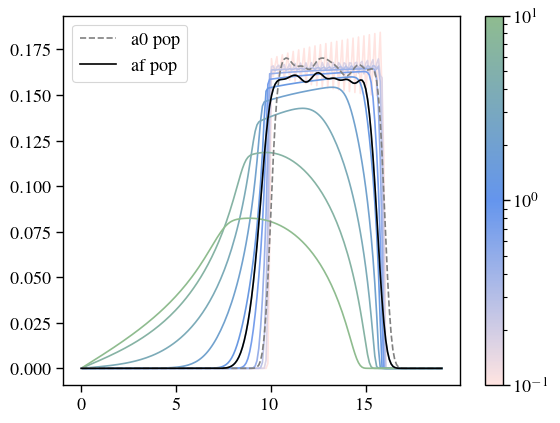

In [83]:
norm = mcolors.LogNorm(vmin=rates.min(), vmax=rates.max())
cmap = mycmap()

fig,ax = plt.subplots()

[ax.plot(ap,p,c=cmap(norm(k))) for k,p in p_af_preds.items()]
ax.plot(ap,scp_kde(af_pop,ap))
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax)

ax.plot(ap,p_a0_obs_val,label='a0 pop',c='grey',linestyle='--')
ax.plot(ap,scp_kde(af_pop,ap),label='af pop',c='k')
# ax.hist(af_pop, density=True,alpha=0.1,color='k')
ax.legend();

# 2. Sample from population